In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [103]:
words=open('names.txt', 'r').read().splitlines()
print(words[:10:])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
32033


In [104]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [120]:
#splitting the dataset intro train(80%), dev(10%),test(10%)

def build_dataset(words):
    block_size=5              #no. of elements in our context used to predict the next char 
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]        #updating last (3rd) element in context block


    X=torch.tensor(X)
    Y =torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y


import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xtest,Ytest=build_dataset(words[n2:])

torch.Size([182580, 5]) torch.Size([182580])
torch.Size([22767, 5]) torch.Size([22767])
torch.Size([22799, 5]) torch.Size([22799])


In [121]:
g=torch.Generator().manual_seed(2147483647)

#initializing 10-d embeddings for all 27 of our characters
C=torch.randn((27,10),generator=g)

#creating hyperparamters
W1=torch.randn((50,200),generator=g)
b1=torch.randn((200),generator=g)

W2=torch.randn((200,27),generator=g)
b2=torch.randn((27),generator=g)

In [122]:
emb=C[Xtr]  #extracting embeddings of samples stored in X
print("emb shape:",emb.shape,"\n")

h=torch.tanh(emb.view(-1,50) @ W1 + b1 )      #calculating 2nd layer
print("h shape:",h.shape,"\n",h)

logits=h @ W2 +b2                           #calculating 3rd layer
print("logits shape:",logits.shape,"\n",logits)

emb shape: torch.Size([182580, 5, 10]) 

h shape: torch.Size([182580, 200]) 
 tensor([[-1.0000,  0.9126, -1.0000,  ...,  0.9660,  1.0000, -0.9097],
        [-1.0000,  1.0000, -0.9900,  ...,  0.6330,  1.0000,  0.9996],
        [-1.0000,  0.2434,  0.9986,  ..., -1.0000,  1.0000,  0.4006],
        ...,
        [ 0.9994, -0.9995,  0.9967,  ..., -1.0000, -0.9996,  1.0000],
        [-0.9998, -1.0000, -1.0000,  ..., -0.9992, -0.6102, -1.0000],
        [-1.0000, -0.9977, -1.0000,  ...,  0.3077, -0.9996, -1.0000]])
logits shape: torch.Size([182580, 27]) 
 tensor([[ -1.1919,  18.8674, -10.1908,  ...,  -6.5353,   5.6279,  13.1797],
        [ 15.7845,  22.4544,  -9.2070,  ...,   0.9486,  -7.6784,  18.5472],
        [  8.2222,  -2.3664, -14.1048,  ..., -15.0463,   2.4419,  18.2352],
        ...,
        [ -1.1341,  -4.9892,   7.5562,  ...,   8.9320,   0.8985, -19.6796],
        [-12.6969, -13.6580,   0.9959,  ...,   0.5239,  -5.8517, -14.1740],
        [-14.1181, -21.8034,   3.1724,  ...,   0.6241,

In [125]:
loss=F.cross_entropy(logits,Ytr)  #Y contains all the actual labels of our samples in X
loss.item()
lossarr=[loss.item()]  #initial loss without any optimization

In [126]:
lossarr

[23.3465518951416]

In [127]:
#backward pass
parameters=[C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad=True    

In [128]:

#training on a mini batch of the train split
for i in range(10000):
    ix=torch.randint(0,Xtr.shape[0],(10000,))
    emb=C[Xtr[ix]]
    h=torch.tanh(emb.view(-1,50)@ W1 +b1)  #(100,300)
    logits=h @ W2 +b2    #(100,27)
    loss=F.cross_entropy(logits,Ytr[ix])

    #gradient descent
    for p in parameters:
        p.grad =None
    loss.backward()

    lr=0.1 if i <9000 else 0.01     

    for p in parameters:
        p.data+= -lr * p.grad
    lossarr.append(loss.item()) 
print(loss.item())         

2.2635419368743896


In [117]:
#noting convergence with each iteration
for i,loss in enumerate(lossarr):
    print(i,loss)
    

0 23.331432342529297
1 25.291236877441406
2 22.336130142211914
3 18.805015563964844
4 20.014057159423828
5 23.14086151123047
6 20.08647918701172
7 20.63300323486328
8 23.228849411010742
9 20.538251876831055
10 18.929441452026367


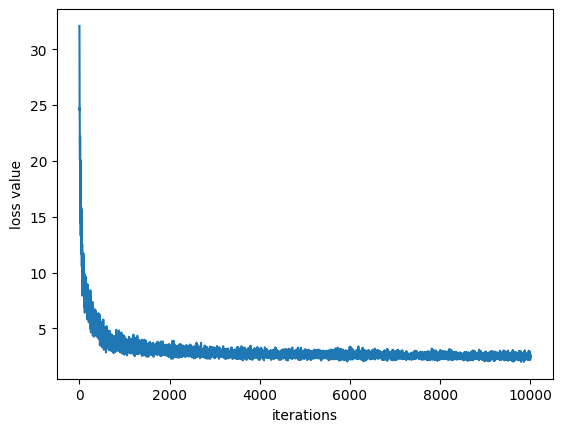

In [99]:
plt.plot(range((len(lossarr))),lossarr)
plt.xlabel("iterations")
plt.ylabel("loss value")
plt.show()

In [130]:
#loss on the dev dataset after mini batch optimization of training set
emb=C[Xdev]
h=torch.tanh(emb.view(-1,50) @ W1 +b1)
logits= h @ W2 + b2
loss=F.cross_entropy(logits,Ydev)
print(loss.item())


2.278048515319824


In [ ]:
#sampling from the model
g=torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out =[]
    context=[0]*5
    while True:
        emb=C[torch.tensor([context])]